CREATE DATABASE shipping_db;
USE shipping_db;
CREATE TABLE shipments (
shipment_id INT PRIMARY KEY,
port VARCHAR(50),
shipment_date DATE,
status VARCHAR(20)
);
CREATE TABLE shipment_delay (
shipment_id INT,
delay_reason VARCHAR(100),
delay_days INT
);
INSERT INTO shipments VALUES
(1,'Mumbai','2024-01-01','Delivered'),
(2,'Chennai','2024-01-02','Delayed'),
(3,'Mumbai','2024-01-03','Delivered'),
(4,'Kolkata','2024-01-04','Delayed'),
(5,'Chennai','2024-01-05','Delivered');
INSERT INTO shipment_delay VALUES
(2,'Weather',2),
(4,'Port Congestion',3);

Python Libraries

In [1]:
!pip install pandas mysql-connector-python matplotlib openai

Defaulting to user installation because normal site-packages is not writeable


Connect Python to MySQL

In [2]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
host="localhost",
user="root",
password="",
database="shipping_db"
)

query = """
SELECT 
s.shipment_id,
s.port,
s.status,
d.delay_reason
FROM shipments s
LEFT JOIN shipment_delay d
ON s.shipment_id = d.shipment_id
"""

df = pd.read_sql(query, conn)

print(df)

   shipment_id     port     status     delay_reason
0            2  Chennai    Delayed          Weather
1            4  Kolkata    Delayed  Port Congestion
2            1   Mumbai  Delivered             None
3            3   Mumbai  Delivered             None
4            5  Chennai  Delivered             None


C:\Users\panka\AppData\Local\Temp\ipykernel_24500\2992317016.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Calculate Delay Rate per Port

Total Shipments

In [3]:
total_shipments = df.groupby("port")["shipment_id"].count()

Delayed Shipments

In [4]:
delayed = df[df["status"]=="Delayed"]
delayed_shipments = delayed.groupby("port")["shipment_id"].count()

Delay Rate

In [5]:
delay_rate = (delayed_shipments / total_shipments) * 100
delay_rate = delay_rate.fillna(0)
print(delay_rate)

port
Chennai     50.0
Kolkata    100.0
Mumbai       0.0
Name: shipment_id, dtype: float64


Analyze Delay Reasons

In [6]:
reason_counts = delayed["delay_reason"].value_counts()
print(reason_counts)

delay_reason
Weather            1
Port Congestion    1
Name: count, dtype: int64


Visualization

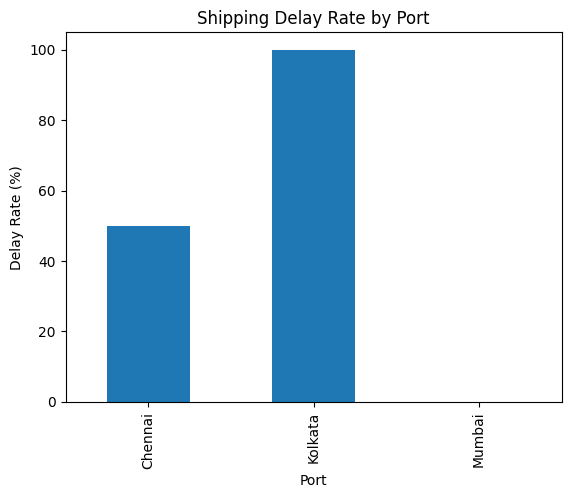

In [7]:
import matplotlib.pyplot as plt
delay_rate.plot(kind="bar")
plt.title("Shipping Delay Rate by Port")
plt.xlabel("Port")
plt.ylabel("Delay Rate (%)")
plt.show()

Delay Reasons Chart

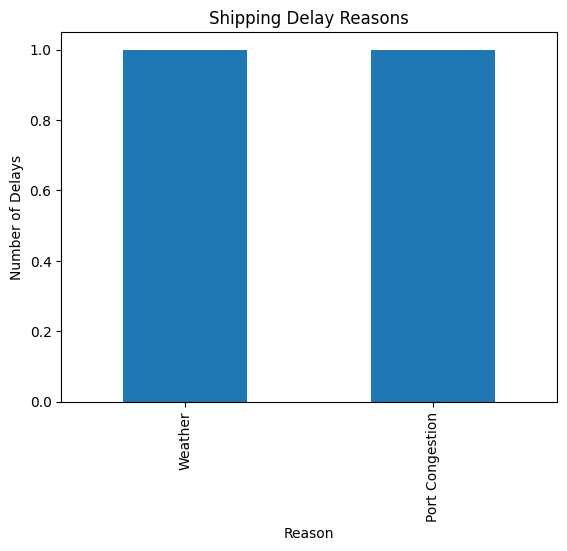

In [8]:
reason_counts.plot(kind="bar")
plt.title("Shipping Delay Reasons")
plt.xlabel("Reason")
plt.ylabel("Number of Delays")
plt.show()

In [9]:
from openai import OpenAI

client = OpenAI()

summary = delay_rate.to_string()

response = client.responses.create(
model="gpt-4.1-mini",
input=f"""
Analyze shipping delay rates by port and suggest operational improvements:

{summary}
"""
)

print(response.output_text)

### Shipping Delay Rates by Port Analysis:

| Port     | Delay Rate (%) |
|----------|----------------|
| Chennai  | 50.0           |
| Kolkata  | 100.0          |
| Mumbai   | 0.0            |

### Observations:
1. **Kolkata** is experiencing the highest delay rate at 100%, indicating severe operational issues causing all shipments to be delayed.
2. **Chennai** has a substantial delay rate at 50%, meaning half the shipments face delays.
3. **Mumbai** shows excellent performance with 0% delay, indicating efficient operations.

---

### Suggested Operational Improvements:

1. **Kolkata Port:**
   - **Root Cause Analysis:** Conduct a detailed investigation to determine the major causes of delays—could be congestion, lack of equipment, staffing issues, or customs bottlenecks.
   - **Infrastructure Upgrade:** Invest in better cargo handling equipment and expand berths to reduce congestion.
   - **Process Optimization:** Streamline paperwork and customs clearance with digital solutions to a